In [1]:
import numpy as np
import xarray
import os
from matplotlib import pyplot as plt
import scipy.signal as scipy_signal
import scipy.stats as scipy_stats
from geopy import distance as geo_dist
import cmocean
import pandas
import proplot
import cartopy.feature as cfeature

/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/_collections_abc.py:841: MatplotlibDeprecationWarning: 
The examples.directory rcparam was deprecated in Matplotlib 3.0 and will be removed in 3.2. In the future, examples will be found relative to the 'datapath' directory.
  self[key] = other[key]


In [2]:
track_file_path = '/tube1/cha674/Tropical_Turtles/imos_turtles22_final_prof/'
olive_ridley_dir = 'tu117'
flatback_dir     = 'tu120'


olive_ridley_files = os.listdir(os.path.join(track_file_path,olive_ridley_dir))
olive_ridley_files_list = []

for i_file in olive_ridley_files:
    
    if i_file.endswith('_hr0_prof.nc'):
        olive_ridley_files_list.append(os.path.join(track_file_path,olive_ridley_dir,i_file))
        

flatback_files = os.listdir(os.path.join(track_file_path,flatback_dir))
flatback_files_list = []

for i_file in flatback_files:
    
    if i_file.endswith('_hr0_prof.nc'):
        flatback_files_list.append(os.path.join(track_file_path,flatback_dir,i_file))


turtle_files = olive_ridley_files_list + flatback_files_list



#track_data_frame = pandas.read_csv(track_file_name)

In [73]:
first_pass = True


turtle_dataframe  = {} #{'id':[],'lat':[],'lon':[],'time':[]}


for i_turtle in turtle_files:
    turtle_ds = xarray.open_dataset(i_turtle)
    time = xarray.CFTimeIndex(turtle_ds['JULD'].values).to_datetimeindex()
    
    if first_pass:
        min_time = time.min()
        max_time = time.max()
        
        turtle_dataframe['id'] = turtle_ds['PLATFORM_NUMBER'].values.astype('int')
        turtle_dataframe['lat'] = turtle_ds['LATITUDE'].values
        turtle_dataframe['lon'] = turtle_ds['LONGITUDE'].values
        turtle_dataframe['date'] = time


        
        first_pass = False
    else:
        if time.min()<min_time:
            min_time = time.min()
        if time.max()>max_time:
            max_time = time.max()
            
        turtle_dataframe['id']   = np.concatenate([turtle_dataframe['id'], turtle_ds['PLATFORM_NUMBER'].values.astype('int')])
        turtle_dataframe['lat']  = np.concatenate([turtle_dataframe['lat'], turtle_ds['LATITUDE'].values])
        turtle_dataframe['lon']  = np.concatenate([turtle_dataframe['lon'], turtle_ds['LONGITUDE'].values])
        turtle_dataframe['date'] = np.concatenate([turtle_dataframe['date'], time])


turtle_dataframe = pandas.DataFrame(data=turtle_dataframe)

/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  if __name__ == "__main__":


In [74]:
turtle_dataframe

,id,lat,lon,date
0,99316,-11.1905,130.4067,2022-05-28 22:04:59.999999
1,99316,-11.0841,130.4509,2022-05-29 03:39:59.999998
2,99316,-11.0454,130.4272,2022-05-29 09:59:59.999997
3,99316,-11.0179,130.2965,2022-05-29 21:39:59.999998
4,99316,-11.0152,130.3036,2022-05-29 23:49:59.999996
...,...,...,...,...
6503,99365,-11.8013,135.3236,2022-10-19 17:40:00.000001
6504,99365,-11.7969,135.3355,2022-10-19 21:59:59.999997
6505,99365,-11.8009,135.3446,2022-10-20 04:55:00.000001
6506,99365,-11.8101,135.3875,2022-10-20 21:05:00.000002


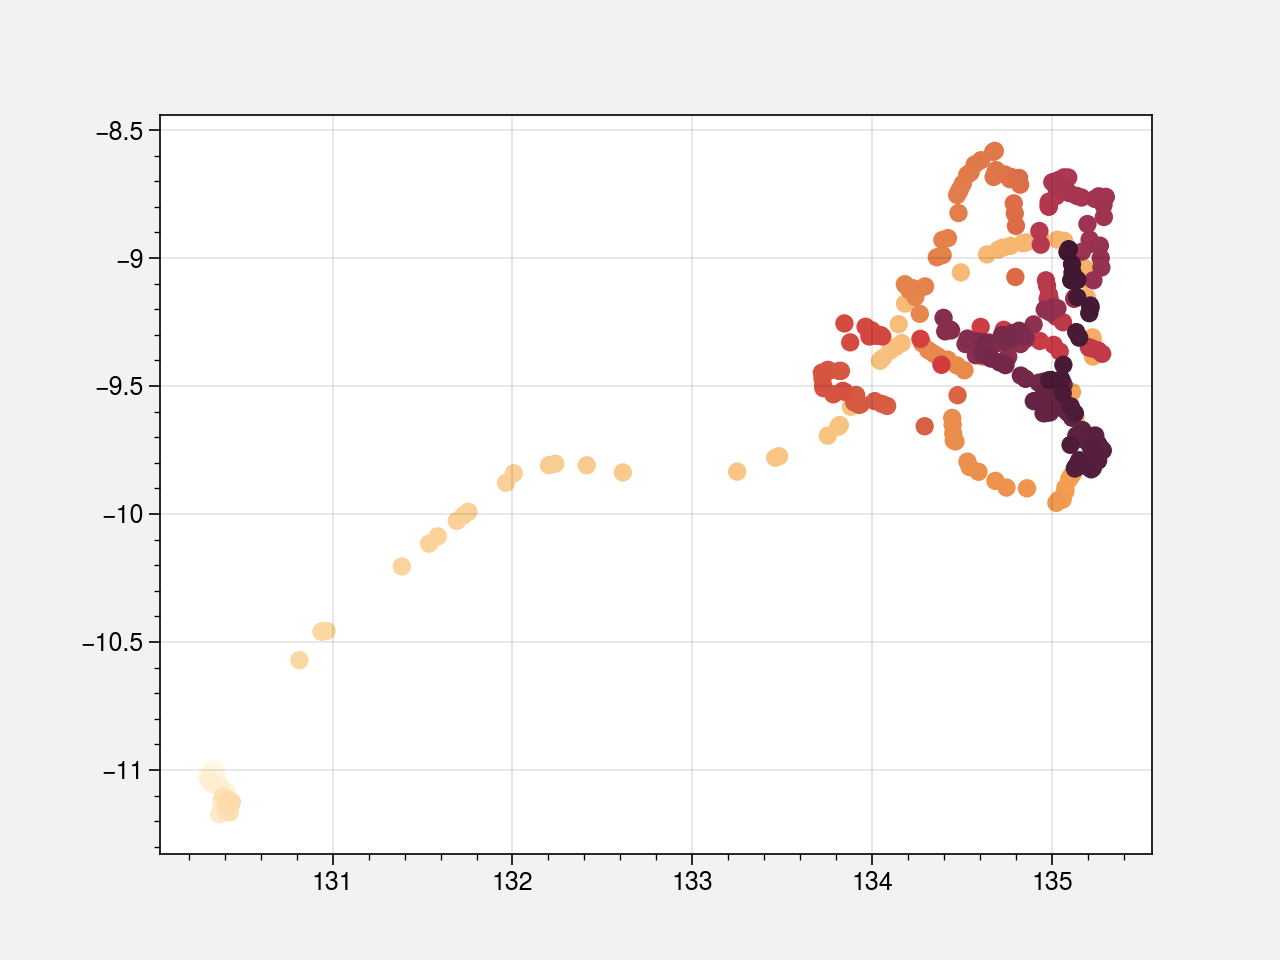

In [42]:
plt.scatter(turtle_file['LONGITUDE'],turtle_file['LATITUDE'],c=pandas.to_datetime(time))

In [23]:
albatross = track_data_frame.loc[track_data_frame['species'] == 'AUSFS']


In [24]:
unique_ids = albatross['id'].unique()
print(len(unique_ids))

5


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.
No handles with labels found to put in legend.


TypeError: __init__() missing 2 required positional arguments: 'handles' and 'labels'

<Figure size 2000x1000 with 0 Axes>

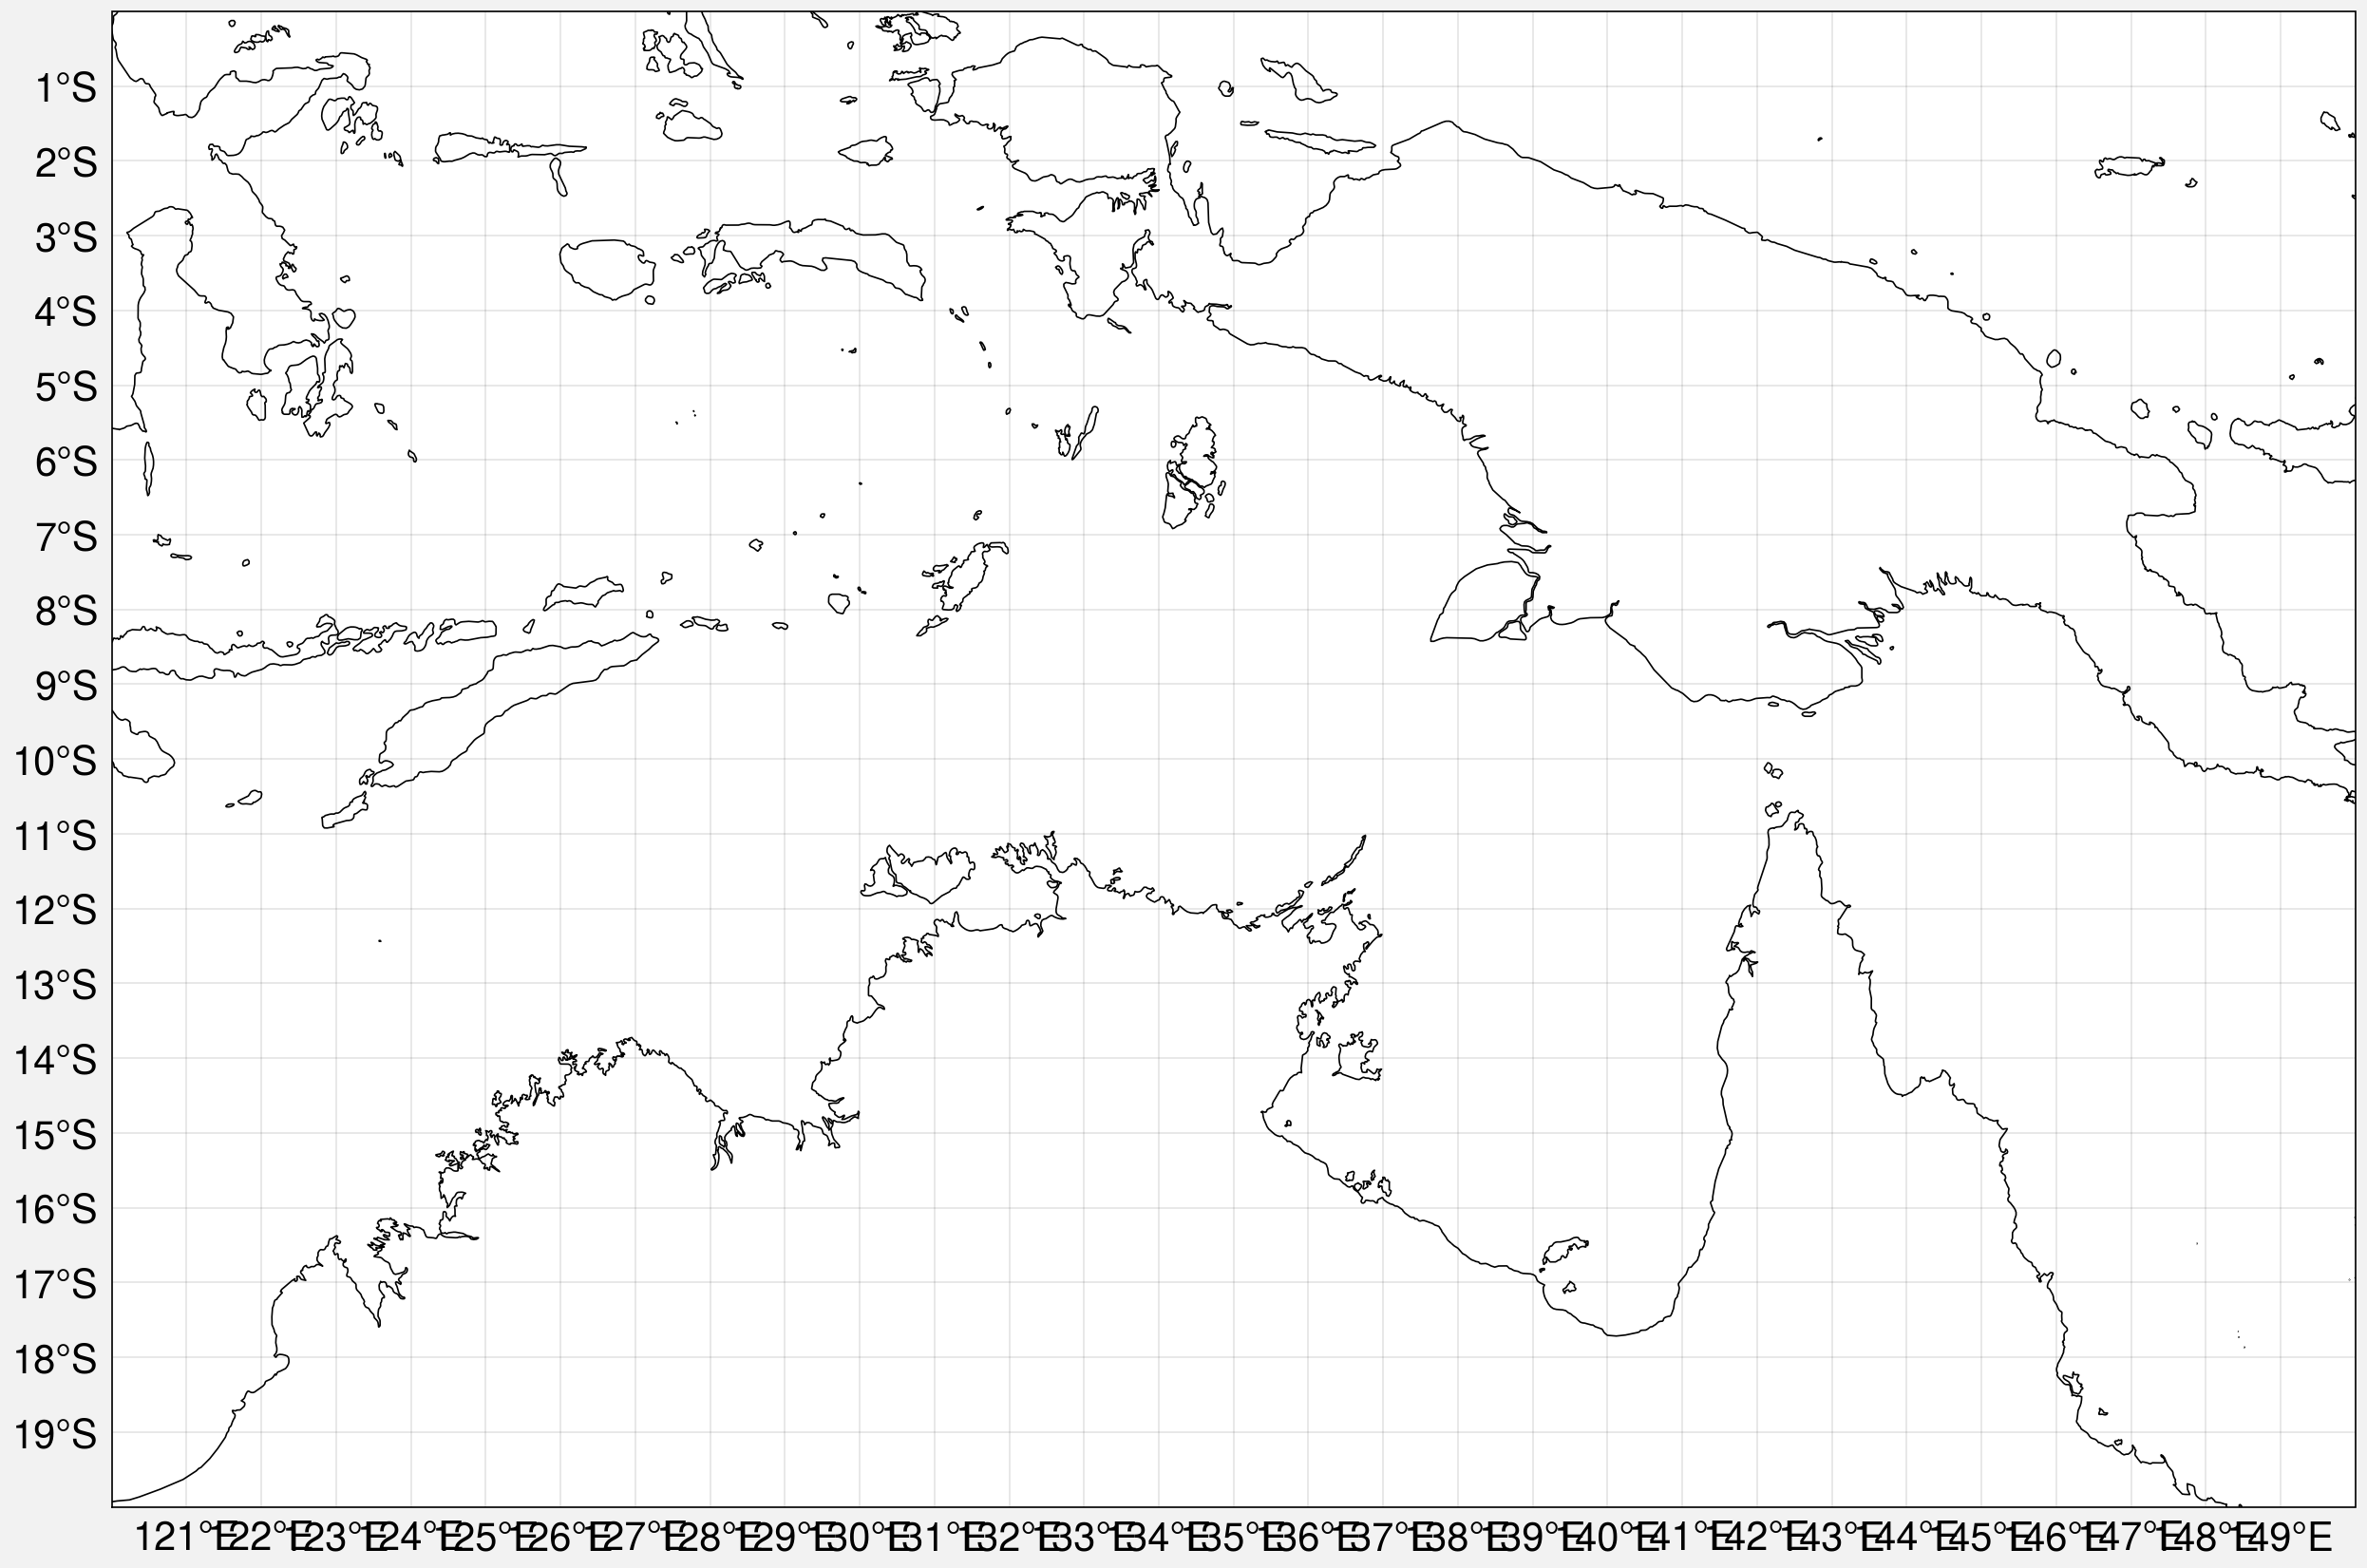

In [159]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes,mark_inset
import cartopy
import cartopy.crs as ccrs
from shapely.geometry.polygon import LinearRing


unique_ids = turtle_dataframe['id'].unique()






proplot.rc['land.color'] = 'grey'
proplot.rc['text.labelsize'] = 15
proplot.rc['text.titlesize'] = 25
proplot.rc['abc.size'] = 15
proplot.rc['abc.style'] = 'a'
proplot.rc.reso = 'hi'

#SW Tas Domain
lon_min = 120
lon_max = 150
lat_min = -20
lat_max = 0

start_date = pandas.Timestamp('2023-04-06')
end_date   = pandas.Timestamp('2023-04-15')


proj = proplot.Proj('cyl', basemap=False)


plt.figure(1,figsize=(20,10))
fig, axs = proplot.subplots(nrows=1, ncols=1,axwidth='30cm',aspect=2.5,proj=proj)
axs.format(abc=False,share=0) #, color='grey')


for i_animal in unique_ids:
#for i_animal in  [99354]:
    animal_to_follow = turtle_dataframe.loc[turtle_dataframe['id'] == i_animal ]
    mask             = (animal_to_follow['date'] > start_date) & (animal_to_follow['date'] <= end_date)
    if any(mask):
    
        animal_to_follow = animal_to_follow.loc[animal_to_follow[time]>start_date] # and animal_to_follow[time]>end_date]
    
        lat_animal = animal_to_follow['lat']
        lon_animal = animal_to_follow['lon']
        time_animal = pandas.to_datetime(animal_to_follow['date'].values)
        axs[0].scatter(lon_animal,lat_animal,label=str(i_animal),cycle='tab20')

axs[0].format(land=False,coast=True,facecolor='white',
                            lonlim=(lon_min, lon_max), latlim=(lat_min, lat_max), 
                            labels=True,lonlines=np.arange(0,360,1),latlines=np.arange(-80,50,1))
axs[0].legend(loc='lr',ncol=1)


In [158]:
if any(mask):
    print('Yes')
else:
    print('Nup')
#pandas.to_datetime(animal_to_follow[time])>start_date

Nup


/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


<Figure size 2000x1000 with 0 Axes>

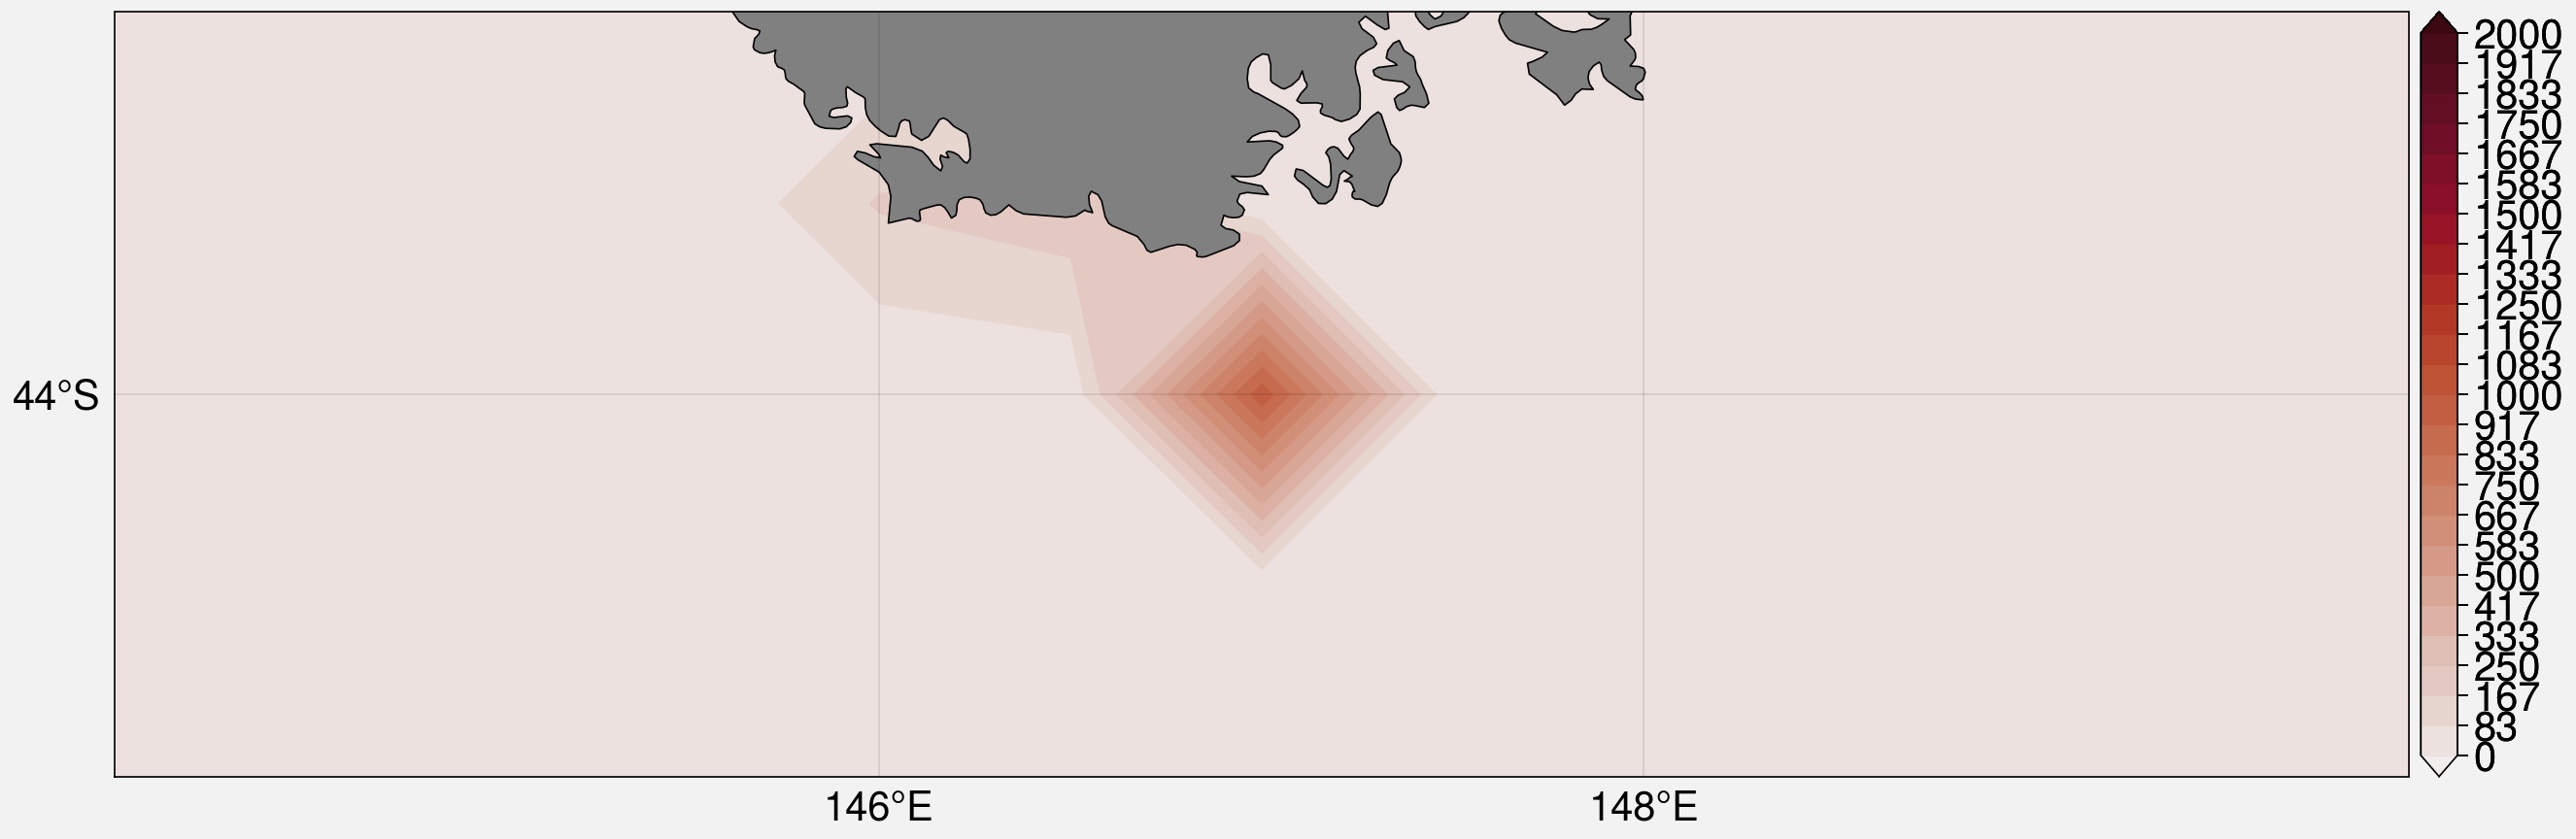

In [30]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes,mark_inset
import cartopy
import cartopy.crs as ccrs
from shapely.geometry.polygon import LinearRing


#SW Tas Domain
#SW Tas Domain
lon_min = 130
lon_max = 140
lat_min = -
lat_max = -43

delta_lon = 0.5
delta_lat = 0.5

xgrid = np.arange(lon_min,lon_max+delta_lon,delta_lon)
ygrid = np.arange(lat_min,lat_max+delta_lat,delta_lat)

X, Y = np.meshgrid(xgrid, ygrid[::-1])
xy = np.vstack([Y.ravel(), X.ravel()]).T
xy *= np.pi / 180.0



Xtrain = np.vstack([albatross["lat"],albatross["lon"]]).T
Xtrain = (np.pi/180.0)*Xtrain  # Convert lat/long to radians

kde = KernelDensity(bandwidth=0.001, metric="haversine", kernel="gaussian", algorithm="ball_tree")
KDE_fit = kde.fit(Xtrain).score_samples(xy)
KDE_fit = np.exp(KDE_fit.reshape(X.shape))

start_date = pandas.Timestamp('2023-04-0    if any(animal_to_follow['date']>start_date):
6')
end_date   = pandas.Timestamp('2023-04-15')




proplot.rc['land.color'] = 'grey'
proplot.rc['text.labelsize'] = 15
proplot.rc['text.titlesize'] = 25
proplot.rc['abc.size'] = 15
proplot.rc['abc.style'] = 'a'
proplot.rc.reso = 'hi'

proj = proplot.Proj('cyl', basemap=False)


plt.figure(1,figsize=(20,10))
fig, axs = proplot.subplots(nrows=1, ncols=1,axwidth='30cm',aspect=2.5,proj=proj)
axs.format(abc=False,share=0) #, color='grey')
cs_kde = axs[0].contourf(X,Y,KDE_fit,levels=np.linspace(0,2000,25),cmap='amp',extend='both')
#axs[0].scatter(albatross["lon"],albatross["lat"],c='k',alpha=0.05)
axs[0].format(land=True,coast=True,facecolor='white',
                            lonlim=(lon_min, lon_max), latlim=(lat_min, lat_max), 
                            labels=True,lonlines=np.arange(0,360,2),latlines=np.arange(-50,50,1))
axs[0].colorbar(cs_kde)

In [ ]:


proplot.rc['land.color'] = 'grey'
proplot.rc['text.labelsize'] = 15
proplot.rc['text.titlesize'] = 25
proplot.rc['abc.size'] = 15
proplot.rc['abc.style'] = 'a'
proplot.rc.reso = 'hi'

#Northern Australia Domain
lon_min = 120
lon_max = 150
lat_min = -20
lat_max = 0




proj = proplot.Proj('cyl', basemap=False)


turtle_date = pandas.to_datetime(turtle_dataframe['date'].values)

animal_colors = proplot.Colors('tab20')

start_date = turtle_date.min()
end_date   = turtle_date.max()


date_range = pandas.date_range(start_date,end_date,freq='1H')

unique_ids = turtle_dataframe['id'].unique()



image_counter = 0
for i_time in range(0,date_range.size-1):
    #(df['column_name'] >= A) & (df['column_name'] <= B)
    #print(sst_time_albatros[i_time])
    #dsa
    tracks_for_date = turtle_dataframe.loc[(turtle_date>date_range[i_time]-np.timedelta64(10,'D')) & (turtle_date<date_range[i_time+1]) ]
    
    
    
    plt.figure(1,figsize=(20,10))
    fig, axs = proplot.subplots(nrows=1, ncols=1,axwidth='30cm',aspect=2.5,proj=proj)
    axs.format(abc=False,share=0) #, color='grey')
    #cs_sst = axs.contourf(sst_dataset['lon'],sst_dataset['lat'],sst_for_albatros['sst'][i_time,:,:],levels=np.linspace(10,22,25),cmap='thermal')
    
    for i_animal in range(0,len(unique_ids)):
        
        animal_to_follow = tracks_for_date.loc[turtle_dataframe['id'] == unique_ids[i_animal]]
        lat_animal  = animal_to_follow['lat'].values
        lon_animal  = animal_to_follow['lon'].values
        time_animal = pandas.to_datetime(animal_to_follow['date'].values)
    
        if len(lat_animal) != 0:
            axs[0].plot(lon_animal,lat_animal,color=animal_colors[i_animal],linestyle='--' )
            axs[0].scatter(lon_animal[-1],lat_animal[-1],c=np.asarray([animal_colors[i_animal]]),markersize=70 )

    
    #END for i_animal
    axs[0].format(land=True,coast=True,facecolor='white',
                            lonlim=(lon_min, lon_max), latlim=(lat_min, lat_max), 
                            labels=True,lonlines=np.arange(0,360,10),latlines=np.arange(-80,50,5))

    
    date_plot_string = date_range[i_time].strftime("%d %B %Y:%H")
    print(date_plot_string)
    #axs[0].colorbar(cs_sst,loc='r',ticks=np.arange(10,22.1,5))
    axs[0].annotate(date_plot_string, xy=(0.05, 1.01), xycoords="axes fraction",fontsize=20)
    
    
    output_path = './Turtle_animation'
    figure_file_name = 'Turtle_frame_' +  str(image_counter).zfill(5)
    
    
    
    plt.savefig(os.path.join(output_path,figure_file_name + '.png'),dpi=100)
    image_counter = image_counter+1
    
    plt.clf()
    
    

In [10]:
single_turtle.close()

In [21]:
single_turtle = xarray.open_dataset(os.path.join('/tube1/cha674/Tasman_Fracture','tu120-619-22_hr1_prof.nc'),decode_times=False)
#single_turtle['date'] = pandas.to_datetime(xarray.CFTimeIndex(single_turtle['JULD'].values).to_datetimeindex())
#date = xarray.CFTimeIndex(single_turtle['JULD'].values).to_datetimeindex()

In [20]:
single_turtle['date']

<xarray.DataArray 'date' (date: 1190)>
array(['2022-10-07T17:34:59.999999000', '2022-10-08T05:54:59.999998000',
       '2022-10-08T11:04:59.999996000', ..., '2024-01-02T00:59:59.999997000',
       '2024-01-03T19:19:59.999996000', '2024-01-04T00:59:59.999997000'],
      dtype='datetime64[ns]')
Coordinates:
  * date     (date) datetime64[ns] 2022-10-07T17:34:59.999999 ... 2024-01-04T...

In [22]:
ref_date = pandas.Timestamp('1950-01-01')
for i_timestamp in single_turtle['JULD'].values:
    turtle_dates = pandas.Timedelta(i_timestamp,'d') + ref_date
    print(turtle_dates)


2022-10-07 17:35:00.000009600
2022-10-08 05:55:00.000019200
2022-10-08 11:05:00.000038400
2022-10-09 04:45:00.000028800
2022-10-09 10:50:00.000009600
2022-10-09 17:19:59.999980800
2022-10-09 22:20:00.000038400
2022-10-10 05:10:00.000019200
2022-10-12 04:34:59.999980800
2022-10-12 10:39:59.999961600
2022-10-12 17:30:00.000028800
2022-10-13 10:50:00.000009600
2022-10-14 04:59:59.999971200
2022-10-15 22:50:00.000009600
2022-10-16 05:05:00.000038400
2022-10-16 16:50:00.000009600
2022-10-16 22:25:00.000019200
2022-10-17 05:30:00.000028800
2022-10-17 11:19:59.999980800
2022-10-23 17:19:59.999980800
2022-10-23 23:15:00
2022-10-24 05:10:00.000019200
2022-10-24 10:59:59.999971200
2022-10-24 17:35:00.000009600
2022-10-24 23:24:59.999961600
2022-10-25 05:35:00.000009600
2022-10-26 02:30:00.000028800
2022-10-26 15:54:59.999961600
2022-10-27 02:19:59.999980800
2022-10-27 09:40:00.000019199
2022-10-27 14:30:00.000028800
2022-10-27 20:10:00.000019200
2022-10-28 08:15:00
2022-10-28 14:19:59.999980800


In [173]:
single_turtle['JULD'].values

array([26577.73263889, 26578.24652778, 26578.46180556, 26579.19791667,
       26579.45138889, 26579.72222222, 26579.93055556, 26580.21527778,
       26582.19097222, 26582.44444444, 26582.72916667, 26583.45138889,
       26584.20833333, 26585.95138889, 26586.21180556, 26586.70138889,
       26586.93402778, 26587.22916667, 26587.47222222, 26593.72222222,
       26593.96875   , 26594.21527778, 26594.45833333, 26594.73263889,
       26594.97569444, 26595.23263889, 26596.10416667, 26596.66319444,
       26597.09722222, 26597.40277778, 26597.60416667, 26597.84027778,
       26598.34375   , 26598.59722222, 26598.83333333, 26599.57638889,
       26600.80208333, 26601.04166667, 26601.31944444, 26601.60069444,
       26601.83333333, 26602.30902778, 26602.56944444, 26602.875     ,
       26603.06597222, 26603.56597222, 26603.85069444, 26604.83333333,
       26605.06944444, 26605.33333333, 26605.57291667, 26606.06944444,
       26606.60763889, 26606.63194444, 26606.83333333, 26607.30902778,
      

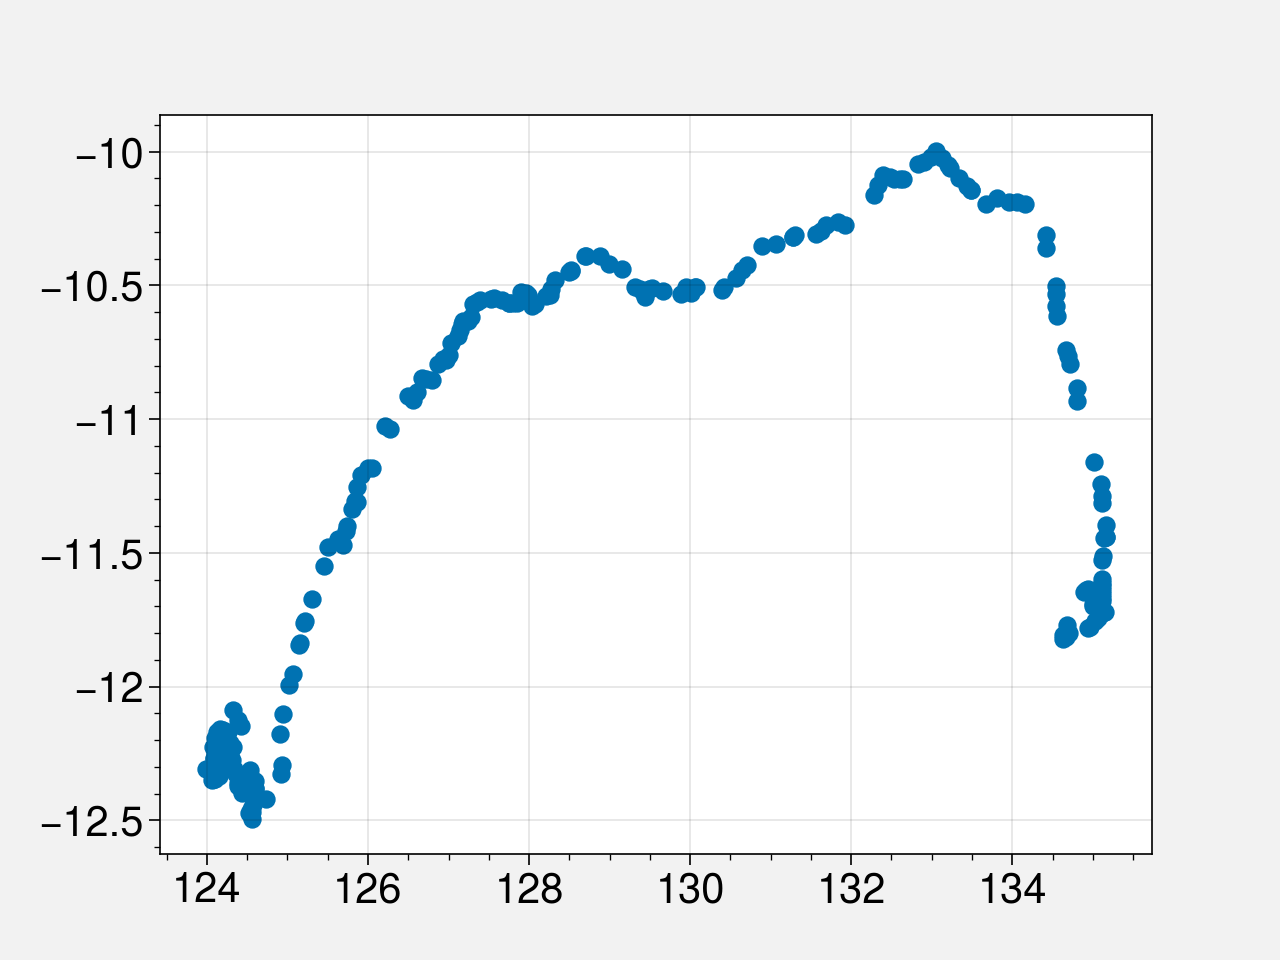

In [137]:
plt.scatter(single_turtle['LONGITUDE'],single_turtle['LATITUDE'])

/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.
/tube1/cha674/Anaconda_Install/miniconda/envs/py3/lib/python3.7/site-packages/proplot/config.py:555: ProPlotWarning: rc setting 'share' was renamed to subplots.share in version 0.6.


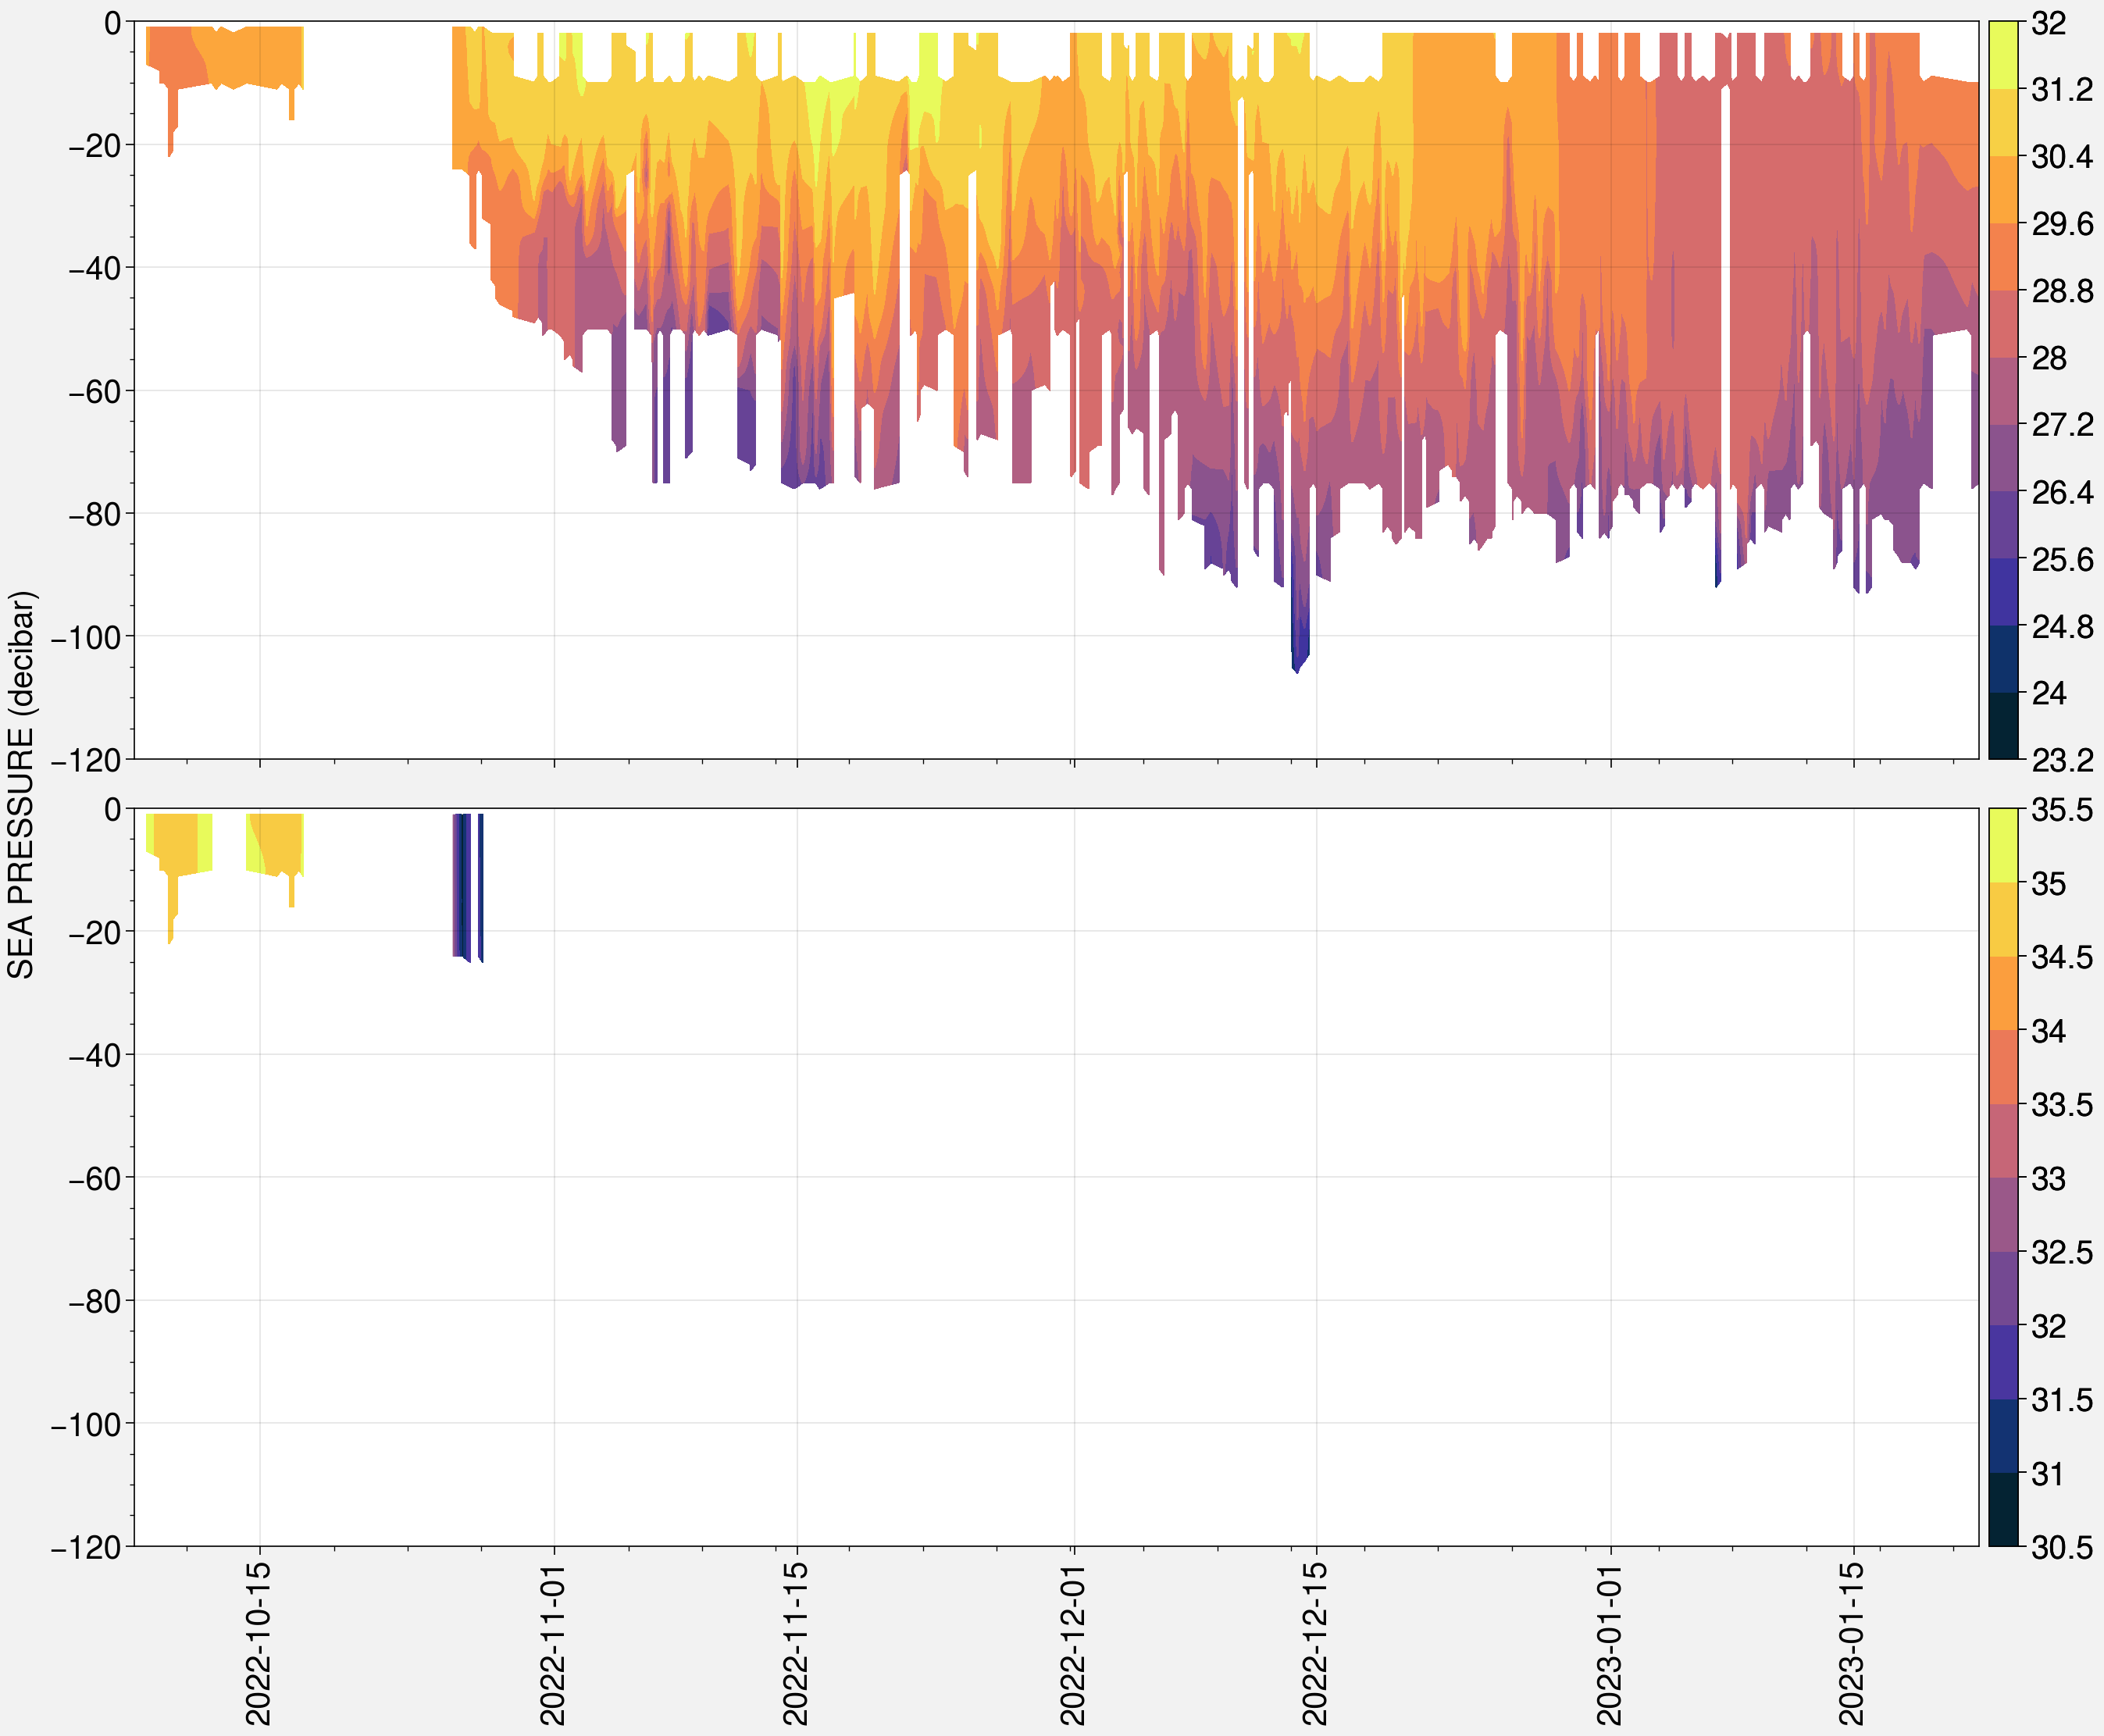

In [142]:

start_date = pandas.Timestamp('2023-04-06')
end_date   = pandas.Timestamp('2023-04-15')

fig, axs = proplot.subplots(nrows=2, ncols=1,axwidth='30cm',aspect=2.5)
axs.format(abc=False,share=0) #, color='grey')



cs = axs[0].contourf(pandas.to_datetime(date),-single_turtle['PRES_ADJUSTED'][0,:],single_turtle['TEMP_ADJUSTED'].T.values,cmap='thermal')
axs[0].set_ylim(-120,0)
#axs[0].set_xlim(start_date,end_date)

axs[0].colorbar(cs)

cs = axs[1].contourf(pandas.to_datetime(date),-single_turtle['PRES_ADJUSTED'][0,:],single_turtle['PSAL_ADJUSTED'].T.values,cmap='thermal')
axs[1].set_ylim(-120,0)
#axs[1].set_xlim(start_date,end_date)
axs[1].colorbar(cs)



In [98]:
single_turtle['JULD'].shape

(290,)

In [111]:
albatros_date[0]

Timestamp('2022-10-01 03:09:00+0000', tz='UTC')